# Montréal Gas Price — Notebook 3: Modelling
**Input:** `montreal_gas_ml_ready.csv` (output from Notebook 2)
**Goal:** Train and evaluate models to predict next-day retail gas price (¢/L)

**Pipeline:**
1. Load & inspect the ML-ready feature matrix
2. Define features and target
3. Hard time-series train / test split
4. Naive persistence baseline
5. Ridge Regression
6. XGBoost
7. LightGBM
8. Model comparison & evaluation
9. Predictions vs actuals
10. Feature importance
11. Residual analysis
12. Walk-forward cross-validation
13. Save best models

**Next:** Notebook 4 — Inference & Budget Estimator

## 0. Install & import

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm joblib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import warnings
import os

PLOTS_DIR  = '../plots'
DATA_DIR   = '../Data'
WEBAPP_DIR = '../webapp'

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 4)
print('Ready.')

Ready.


## 1. Load data

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, 'montreal_gas_ml_ready.csv'))
date_col = 'date' if 'date' in df.columns else 'Unnamed: 0'
df[date_col] = pd.to_datetime(df[date_col])
df = df.set_index(date_col)
df.index.name = 'date'

print(f'Loaded: {len(df):,} rows  {df.index.min().date()} → {df.index.max().date()}')
print(f'Shape : {df.shape}')
df

Loaded: 2,523 rows  2016-08-01 → 2026-03-31
Shape : (2523, 29)


,gas_price,wti_usd,cadusd,wti_cad,gas_lag_1,gas_lag_2,gas_lag_3,gas_lag_5,gas_lag_10,gas_lag_21,wti_cad_lag_1,wti_cad_lag_2,wti_cad_lag_5,gas_roll_mean_5,gas_roll_std_5,gas_roll_mean_10,gas_roll_std_10,gas_roll_mean_21,gas_roll_std_21,wti_cad_roll_mean_5,wti_cad_roll_mean_21,wti_cad_chg_1,wti_cad_chg_5,gas_chg_1,cadusd_chg_1,day_of_week,month,target_price,target_change
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-08-01,102.0,40.05,1.3096,30.581857,102.0,102.4,103.0,106.0,103.8,117.9,31.855828,31.230068,32.062916,103.52,1.616168,104.67,3.274837,106.742857,4.208868,31.752657,34.401244,0.625760,-1.085438,-0.4,-0.0130,0,8,99.8,-2.2
2016-08-02,99.8,39.50,1.3087,30.182624,102.0,102.0,102.4,104.2,102.8,110.5,30.581857,31.855828,31.922465,102.72,0.923038,104.49,3.375878,105.985714,3.466019,31.456445,34.047578,-1.273971,-1.481059,0.0,0.0056,1,8,107.9,8.1
2016-08-03,107.9,40.80,1.3078,31.197431,99.8,102.0,102.0,103.0,101.7,109.3,30.182624,30.581857,31.692005,101.84,1.211610,104.19,3.663772,105.476190,3.554561,31.108477,33.674901,-0.399233,-1.739841,-2.2,-0.0009,2,8,108.2,0.3
2016-08-04,108.2,41.92,1.3025,32.184261,107.9,99.8,102.0,102.4,111.0,108.2,31.197431,30.182624,31.230068,102.82,3.018609,104.81,3.719752,105.409524,3.491834,31.009562,33.442162,1.014807,-0.494574,8.1,-0.0009,3,8,105.5,-2.7
2016-08-05,105.5,41.83,1.3179,31.739889,108.2,107.9,99.8,102.0,109.8,107.1,32.184261,31.197431,31.855828,103.98,3.823872,104.53,3.281615,105.409524,3.491834,31.200400,33.239982,0.986830,0.954193,0.3,-0.0053,4,8,102.5,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,181.8,91.51,1.3799,66.316400,194.4,194.6,186.7,183.5,177.7,152.5,67.698344,65.118822,70.175951,189.34,4.942975,184.83,7.525962,172.114286,14.970915,68.985492,61.882346,2.579522,-2.351270,-0.2,0.0046,2,3,187.3,5.5
2026-03-26,187.3,96.18,1.3849,69.449058,181.8,194.4,194.6,187.5,171.8,152.3,66.316400,67.698344,70.045915,189.00,5.474943,185.24,7.198951,173.509524,14.406211,68.213582,62.759755,-1.381944,-3.859551,-12.6,0.0035,3,3,182.9,-4.4
2026-03-27,182.9,101.26,1.3880,72.953890,187.3,181.8,194.4,186.7,176.4,151.2,69.449058,66.316400,71.888428,188.96,5.489353,186.79,5.436594,175.176190,13.843370,68.094210,63.794640,3.132658,-0.596857,5.5,0.0050,4,3,192.7,9.8


## 2. Define features and target

We predict `target_price` — tomorrow's retail gas price in ¢/L.

**Why we exclude certain columns:**
- `wti_usd`, `cadusd`, `wti_cad` — current-day values not available at prediction time
- `gas_price` — today's price is already captured safely in `gas_lag_1`
- `target_change` — derived from target, would be a data leak

In [4]:
EXCLUDE  = ['gas_price', 'wti_usd', 'cadusd', 'wti_cad', 'target_price', 'target_change']
FEATURES = [c for c in df.columns if c not in EXCLUDE]
TARGET   = 'target_price'

print(f'Features ({len(FEATURES)}):')
for f in FEATURES:
    print(f'  {f}')
print(f'\nTarget: {TARGET}')

Features (23):
  gas_lag_1
  gas_lag_2
  gas_lag_3
  gas_lag_5
  gas_lag_10
  gas_lag_21
  wti_cad_lag_1
  wti_cad_lag_2
  wti_cad_lag_5
  gas_roll_mean_5
  gas_roll_std_5
  gas_roll_mean_10
  gas_roll_std_10
  gas_roll_mean_21
  gas_roll_std_21
  wti_cad_roll_mean_5
  wti_cad_roll_mean_21
  wti_cad_chg_1
  wti_cad_chg_5
  gas_chg_1
  cadusd_chg_1
  day_of_week
  month

Target: target_price


## 3. Train / test split

We use a **hard date cutoff** — never shuffle time series data.

- **Training set:** Aug 2016 → Dec 2023 (~7.5 years)
- **Test set:** Jan 2024 → present (~2+ years, fully out-of-sample)

The test window is a calm post-inflation period — a realistic out-of-sample challenge.

In [5]:
CUTOFF = '2024-01-01'

train = df[df.index <  CUTOFF]
test  = df[df.index >= CUTOFF]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train: {len(train):,} rows  {train.index.min().date()} → {train.index.max().date()}')
print(f'Test : {len(test):,}  rows  {test.index.min().date()}  → {test.index.max().date()}')

Train: 1,936 rows  2016-08-01 → 2023-12-29
Test : 587  rows  2024-01-01  → 2026-03-31


## 4. Evaluation helpers

Three metrics tracked for every model:
- **MAE** — Mean Absolute Error in ¢/L. On average, how far off is the prediction?
- **RMSE** — Root Mean Squared Error. Penalises large errors more heavily than MAE.
- **Directional Accuracy** — % of days where the model correctly predicts price direction (up/down). > 55% is useful in practice; 50% = random coin flip.

In [6]:
def evaluate(name, y_true, y_pred, y_prev):
    """Compute and print MAE, RMSE, and directional accuracy."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5

    actual_dir = np.sign(y_true.values - y_prev.values)
    pred_dir   = np.sign(np.array(y_pred) - y_prev.values)
    # Ignore days where price didn't move (sign = 0)
    mask = actual_dir != 0
    da = (actual_dir[mask] == pred_dir[mask]).mean()

    print(f'{name:<25}  MAE={mae:.3f} ¢/L   RMSE={rmse:.3f} ¢/L   Dir Acc={da:.1%}')
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'DirAcc': da, 'preds': y_pred}

results = []

## 5. Naive baseline — Persistence model

The persistence model predicts tomorrow = today. Since gas prices are highly autocorrelated,
this is a strong baseline — any real model must beat it.

In [7]:
y_baseline = test['gas_lag_1']

res = evaluate('Persistence (baseline)', y_test, y_baseline, test['gas_lag_1'])
results.append(res)

Persistence (baseline)     MAE=1.940 ¢/L   RMSE=2.771 ¢/L   Dir Acc=0.0%


## 6. Ridge Regression

Linear regression with L2 regularisation. Fast, interpretable, and surprisingly competitive
for gas prices since the relationship between lags and next-day price is mostly linear.

Features must be scaled since Ridge is sensitive to feature magnitude.

In [8]:
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_sc, y_train)
y_ridge = ridge.predict(X_te_sc)

res = evaluate('Ridge Regression', y_test, y_ridge, test['gas_lag_1'])
results.append(res)

Ridge Regression           MAE=1.756 ¢/L   RMSE=2.431 ¢/L   Dir Acc=60.3%


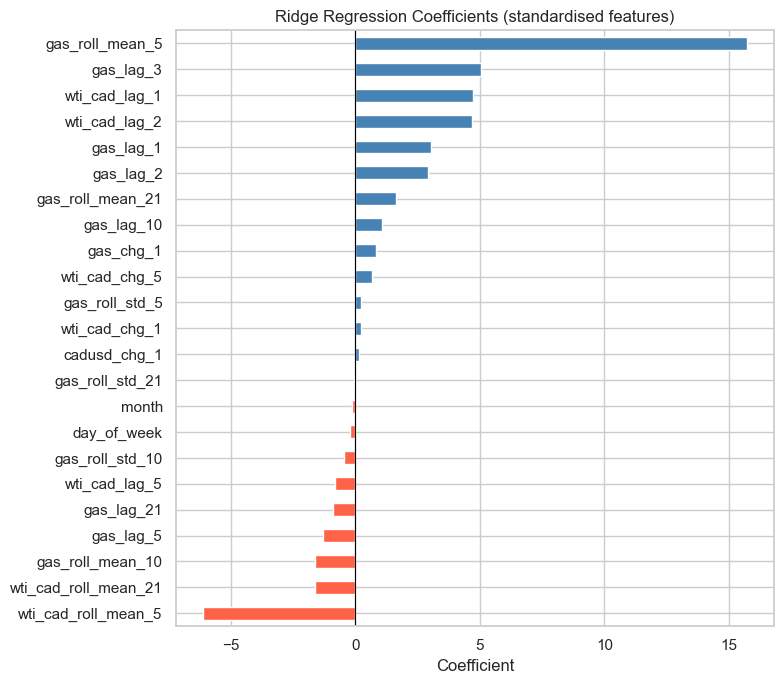

In [9]:
# Ridge coefficients — which features drive the linear model?
coef_df = pd.Series(ridge.coef_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 7))
coef_df.plot(kind='barh',
             color=['steelblue' if v > 0 else 'tomato' for v in coef_df])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Ridge Regression Coefficients (standardised features)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ridge_coefficients.png'), dpi=150)
plt.show()

## 7. XGBoost

Gradient-boosted trees — typically strong for tabular time series with lag features.
Uses early stopping to prevent overfitting: training stops when validation MAE
hasn't improved for 50 consecutive rounds.

In [10]:
xgb = XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 4,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    early_stopping_rounds = 50,
    eval_metric           = 'mae',
    random_state          = 42,
    verbosity             = 0
)

xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

y_xgb = xgb.predict(X_test)
print(f'\nBest iteration: {xgb.best_iteration}')

res = evaluate('XGBoost', y_test, y_xgb, test['gas_lag_1'])
results.append(res)

[0]	validation_0-mae:23.86662
[100]	validation_0-mae:1.87999
[200]	validation_0-mae:1.87605
[230]	validation_0-mae:1.88886

Best iteration: 180
XGBoost                    MAE=1.865 ¢/L   RMSE=2.728 ¢/L   Dir Acc=62.9%


## 8. LightGBM

Similar to XGBoost but uses leaf-wise tree growth — can capture complex interactions
better on smaller datasets and tends to be faster to train.

In [11]:
lgbm = LGBMRegressor(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = 4,
    num_leaves        = 15,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 10,
    n_jobs            = -1,
    random_state      = 42,
    verbose           = -1
)

lgbm.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[])

y_lgbm = lgbm.predict(X_test)

res = evaluate('LightGBM', y_test, y_lgbm, test['gas_lag_1'])
results.append(res)

LightGBM                   MAE=1.965 ¢/L   RMSE=2.816 ¢/L   Dir Acc=63.9%


## 9. Model comparison

In [12]:
summary = pd.DataFrame([
    {'Model': r['name'], 'MAE (¢/L)': round(r['MAE'], 3),
     'RMSE (¢/L)': round(r['RMSE'], 3), 'Dir Acc': f"{r['DirAcc']:.1%}"}
    for r in results
])

print('=== Model Comparison (Test Set) ===')
print(summary.to_string(index=False))

=== Model Comparison (Test Set) ===
                 Model  MAE (¢/L)  RMSE (¢/L) Dir Acc
Persistence (baseline)      1.940       2.771    0.0%
      Ridge Regression      1.756       2.431   60.3%
               XGBoost      1.865       2.728   62.9%
              LightGBM      1.965       2.816   63.9%


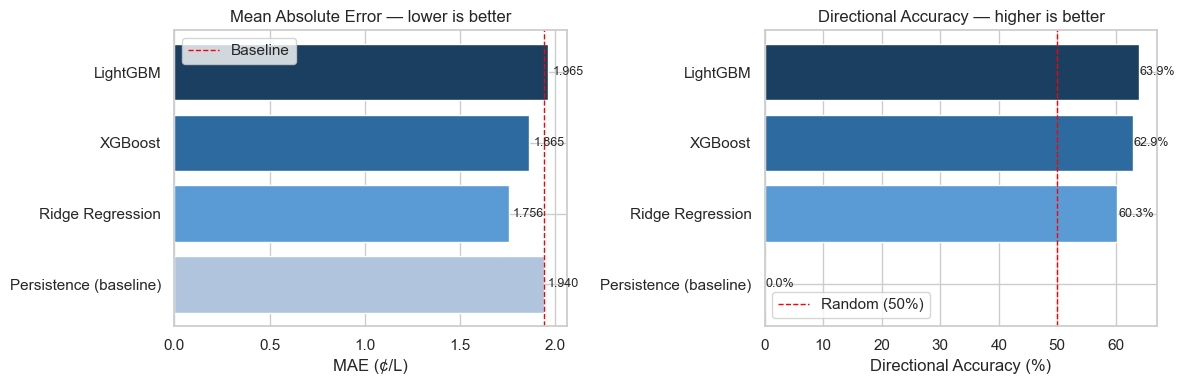

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = [r['name'] for r in results]
maes   = [r['MAE']  for r in results]
das    = [r['DirAcc'] * 100 for r in results]
colors = ['#b0c4de', '#5b9bd5', '#2d6a9f', '#1a3f60']

bars = axes[0].barh(models, maes, color=colors)
axes[0].set_xlabel('MAE (¢/L)')
axes[0].set_title('Mean Absolute Error — lower is better')
axes[0].axvline(maes[0], color='red', linestyle='--', linewidth=1, label='Baseline')
axes[0].legend()
for bar, val in zip(bars, maes):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

bars2 = axes[1].barh(models, das, color=colors)
axes[1].set_xlabel('Directional Accuracy (%)')
axes[1].set_title('Directional Accuracy — higher is better')
axes[1].axvline(50, color='red', linestyle='--', linewidth=1, label='Random (50%)')
axes[1].legend()
for bar, val in zip(bars2, das):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model_comparison.png'), dpi=150)
plt.show()

## 10. Predictions vs actuals — time series plot

Visualising predictions over the full test period reveals whether errors cluster around
specific events or are randomly distributed.

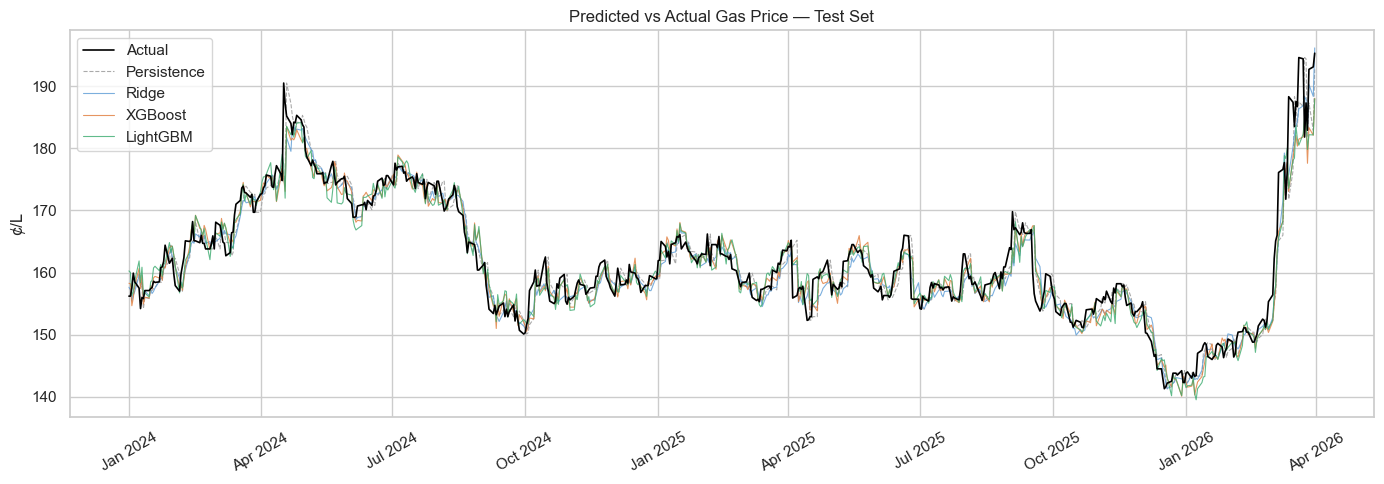

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, y_test,      color='black',   linewidth=1.2, label='Actual',      zorder=5)
ax.plot(test.index, y_baseline,  color='#aaaaaa', linewidth=0.8, label='Persistence', linestyle='--')
ax.plot(test.index, y_ridge,     color='#5b9bd5', linewidth=0.8, label='Ridge',       alpha=0.8)
ax.plot(test.index, y_xgb,       color='#e07b39', linewidth=0.8, label='XGBoost',     alpha=0.8)
ax.plot(test.index, y_lgbm,      color='#3aaa6e', linewidth=0.8, label='LightGBM',    alpha=0.8)

ax.set_title('Predicted vs Actual Gas Price — Test Set')
ax.set_ylabel('¢/L')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'predictions_vs_actuals.png'), dpi=150)
plt.show()

## 11. Feature importance (XGBoost)

Gain-based importance measures how much each feature reduces prediction error
when used in a split. We expect `gas_lag_1` to dominate — prices are sticky.

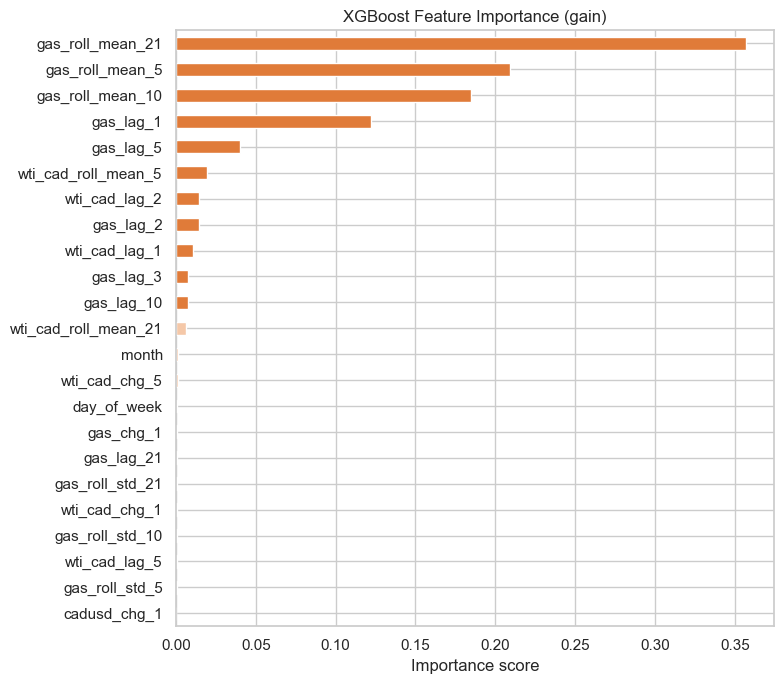

In [15]:
importance = pd.Series(
    xgb.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(8, 7))
importance.plot(
    kind='barh',
    color=['#e07b39' if v > importance.median() else '#f5c8a8' for v in importance]
)
plt.title('XGBoost Feature Importance (gain)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'feature_importance.png'), dpi=150)
plt.show()

## 12. Residual analysis

Examining residuals (actual − predicted) reveals:
- **Random scatter** → model is well-calibrated
- **Clustered large errors** → model struggles during regime shifts
- **Systematic bias** → model consistently over/under-predicts

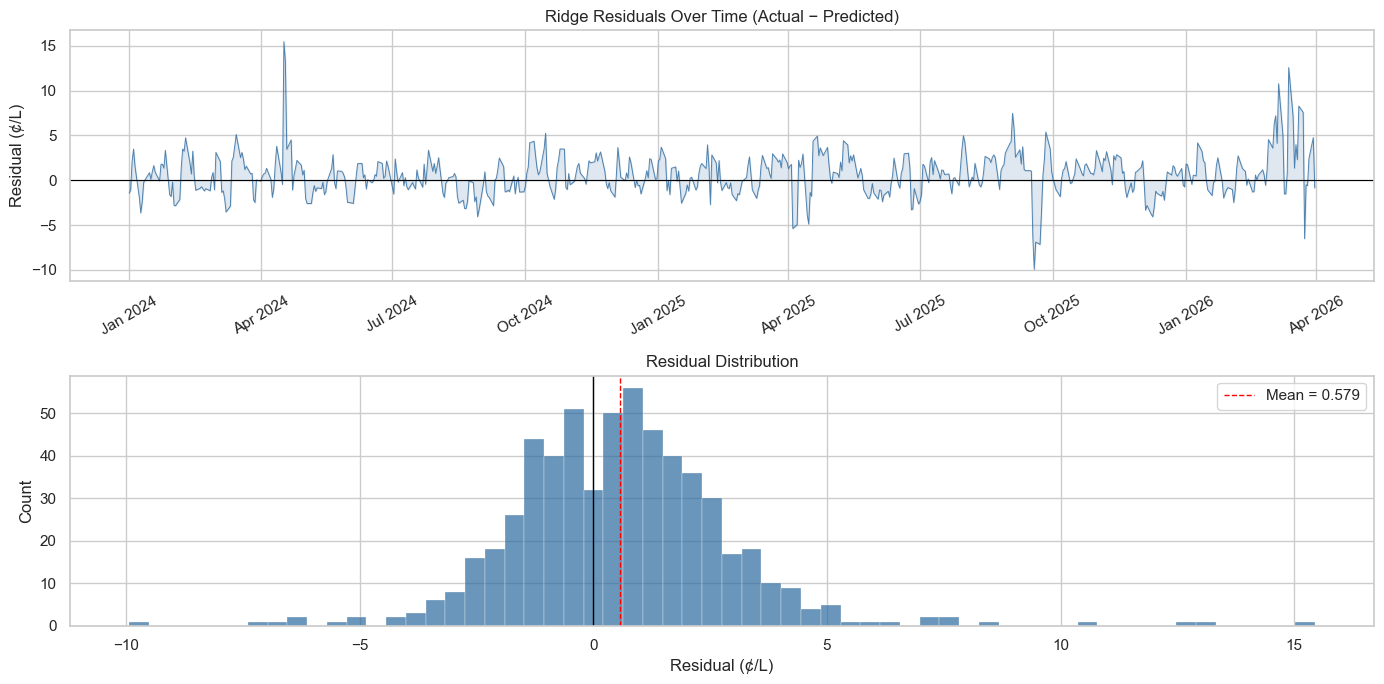

Residual mean : 0.5788 ¢/L  (0 = unbiased)
Residual std  : 2.3611 ¢/L
Max overestimate : -9.93 ¢/L
Max underestimate: 15.44 ¢/L


In [16]:
# Ridge wins on MAE so we use it for residual analysis
best_preds = y_ridge
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(test.index, residuals, color='#2d6a9f', linewidth=0.7, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].fill_between(test.index, residuals, 0, alpha=0.15, color='#2d6a9f')
axes[0].set_title('Ridge Residuals Over Time (Actual − Predicted)')
axes[0].set_ylabel('Residual (¢/L)')
axes[0].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

axes[1].hist(residuals, bins=60, color='#2d6a9f', alpha=0.7, edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].axvline(np.mean(residuals), color='red', linewidth=1, linestyle='--',
                label=f'Mean = {np.mean(residuals):.3f}')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (¢/L)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'residuals.png'), dpi=150)
plt.show()

print(f'Residual mean : {np.mean(residuals):.4f} ¢/L  (0 = unbiased)')
print(f'Residual std  : {np.std(residuals):.4f} ¢/L')
print(f'Max overestimate : {residuals.min():.2f} ¢/L')
print(f'Max underestimate: {residuals.max():.2f} ¢/L')

## 13. Walk-forward cross-validation

Walk-forward CV estimates generalisation error on the training set without touching the test set.
Each fold expands the training window and evaluates on the next block — mimicking real deployment.

In [17]:
tscv   = TimeSeriesSplit(n_splits=5)
cv_maes = []
cv_das  = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        random_state=42, verbosity=0
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    mae        = mean_absolute_error(y_val, preds)
    y_prev_cv  = X_train.iloc[val_idx]['gas_lag_1']
    actual_dir = np.sign(y_val.values - y_prev_cv.values)
    pred_dir   = np.sign(preds - y_prev_cv.values)
    mask       = actual_dir != 0
    da         = (actual_dir[mask] == pred_dir[mask]).mean()

    cv_maes.append(mae)
    cv_das.append(da)
    print(f'  Fold {fold}:  MAE={mae:.3f} ¢/L   Dir Acc={da:.1%}')

print(f'\nCV Mean MAE    : {np.mean(cv_maes):.3f} ± {np.std(cv_maes):.3f} ¢/L')
print(f'CV Mean Dir Acc: {np.mean(cv_das):.1%} ± {np.std(cv_das):.1%}')

  Fold 1:  MAE=9.707 ¢/L   Dir Acc=58.7%
  Fold 2:  MAE=5.364 ¢/L   Dir Acc=48.2%
  Fold 3:  MAE=2.977 ¢/L   Dir Acc=55.6%
  Fold 4:  MAE=27.876 ¢/L   Dir Acc=50.3%
  Fold 5:  MAE=5.357 ¢/L   Dir Acc=54.9%

CV Mean MAE    : 10.256 ± 9.074 ¢/L
CV Mean Dir Acc: 53.5% ± 3.8%


## 14. Save best models

We save Ridge, LightGBM, and the scaler to disk.
Notebook 6 (Inference) loads these directly to generate forecasts — no retraining needed.

**Why we save both Ridge and LightGBM:**
- Ridge has the best MAE — most accurate price level
- LightGBM has the best directional accuracy — best up/down signal
- Notebook 6 uses an ensemble (average of both) for the final forecast

In [18]:
joblib.dump(ridge,  os.path.join(WEBAPP_DIR, 'model_ridge.pkl'))
joblib.dump(lgbm,   os.path.join(WEBAPP_DIR, 'model_lgbm.pkl'))
joblib.dump(scaler, os.path.join(WEBAPP_DIR, 'scaler.pkl'))

print('Saved:')
print(f'  ../webapp/model_ridge.pkl  — Ridge regression (best MAE)')
print(f'  ../webapp/model_lgbm.pkl   — LightGBM (best directional accuracy)')
print(f'  ../webapp/scaler.pkl       — StandardScaler (required for Ridge predictions)')
print()
print('Next: Run Notebook 4 — Inference & Budget Estimator')

Saved:
  ../webapp/model_ridge.pkl  — Ridge regression (best MAE)
  ../webapp/model_lgbm.pkl   — LightGBM (best directional accuracy)
  ../webapp/scaler.pkl       — StandardScaler (required for Ridge predictions)

Next: Run Notebook 4 — Inference & Budget Estimator
